# Keyword Extraction System

##  0. Setup & Installation

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.decomposition import PCA

from keybert import KeyBERT

from collections import Counter
from wordcloud import WordCloud
from IPython.display import display



print('✅ All imports successful!')

✅ All imports successful!


## 1.  Load Dataset

In [34]:
df = pd.read_csv('D:\keyword_extraction_system/data/science_ie_dataset.csv')

print(f'✅ Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns')
print('\nColumns:', df.columns.tolist())
print()
display(df.head(3))

✅ Dataset loaded: 350 rows x 4 columns

Columns: ['id', 'text', 'keyphrases', 'relations']



,id,text,keyphrases,relations
0,S221266781300018X,Amodel are proposed for modeling data-centric ...,"[{'id': 'T1', 'start': 24, 'end': 58, 'type': ...","[{'arg1': 'T4', 'arg2': 'T3', 'relation': 1, '..."
1,S000926141301539X,In this Letter we revisit the Chesnavich model...,"[{'id': 'T1', 'start': 140, 'end': 162, 'type'...","[{'arg1': 'T6', 'arg2': 'T11', 'relation': 1, ..."
2,S0009261412013838,Experimental studies of the dynamics of indivi...,"[{'id': 'T1', 'start': 51, 'end': 63, 'type': ...","[{'arg1': 'T3', 'arg2': 'T27', 'relation': 1, ..."


In [35]:
# ── Auto-detect text and keyword columns ──
TEXT_COL = None
for c in ['abstract', 'text', 'sentence', 'content', 'Abstract', 'Text']:
    if c in df.columns:
        TEXT_COL = c
        break
if TEXT_COL is None:
    TEXT_COL = df.columns[0]

KW_COL = None
for c in ['keywords', 'keyphrases', 'key_phrases', 'keyword', 'labels', 'tags']:
    if c in df.columns:
        KW_COL = c
        break

print(f'Text column    : "{TEXT_COL}"')
print(f'Keywords column: {chr(34)+KW_COL+chr(34) if KW_COL else "Not found — qualitative eval only"}')

df = df.dropna(subset=['text']).reset_index(drop=True)
print(f'Rows after dropping nulls: {len(df)}')

Text column    : "text"
Keywords column: "keyphrases"
Rows after dropping nulls: 350


## 2. Exploratory Data Analysis (EDA)

In [36]:
df['word_count']  = df['text'].apply(lambda x: len(x.split()))
df['text_length'] = df['text'].apply(len)
print(df[['word_count', 'text_length']].describe().round(1))

       word_count  text_length
count       350.0        350.0
mean        159.6       1049.6
std          46.5        296.4
min          60.0        426.0
25%         127.0        830.0
50%         160.0       1054.0
75%         196.8       1285.2
max         271.0       1674.0


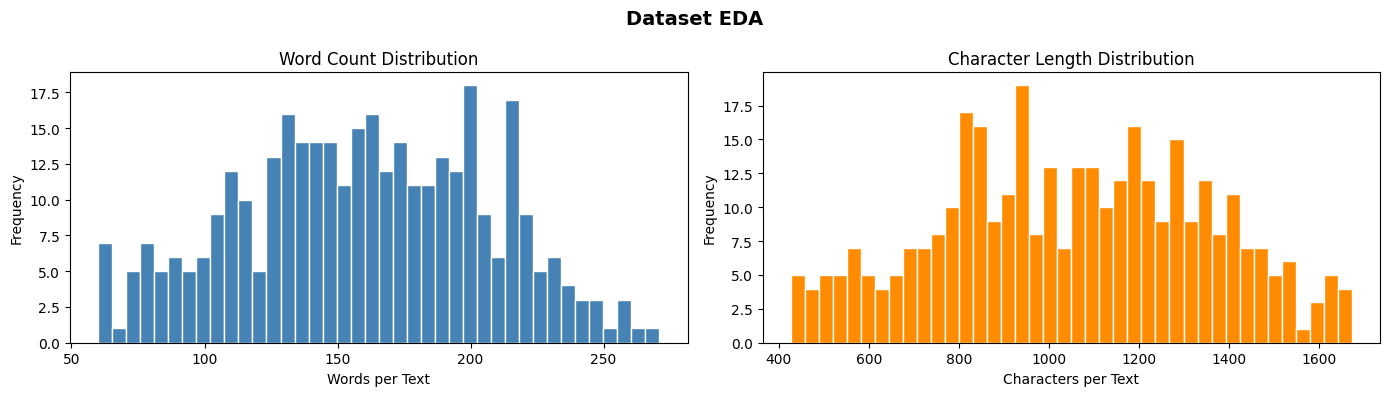

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Dataset EDA', fontsize=14, fontweight='bold')

axes[0].hist(df['word_count'],  bins=40, color='steelblue',  edgecolor='white')
axes[0].set_title('Word Count Distribution')
axes[0].set_xlabel('Words per Text')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['text_length'], bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Character Length Distribution')
axes[1].set_xlabel('Characters per Text')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

##  3. Preprocessing

In [38]:
from src.preprocessing import preprocess_text

df['processed_text'] = df['text'].apply(preprocess_text)

print('=== Before ===')
print(df['text'].iloc[0][:300])
print('\n=== After ===')
print(df['processed_text'].iloc[0][:300])

=== Before ===
Amodel are proposed for modeling data-centric Web services which are powered by relational databases and interact with users according to logical formulas specifying input constraints, control-flow constraints and state/output/action rules. The Linear Temporal First-Order Logic (LTL-FO) formulas ove

=== After ===
amodel proposed modeling data centric web service powered relational database interact user according logical formula specifying input constraint control flow constraint state output action rule linear temporal first order logic ltl fo formula input state output action used express property verified


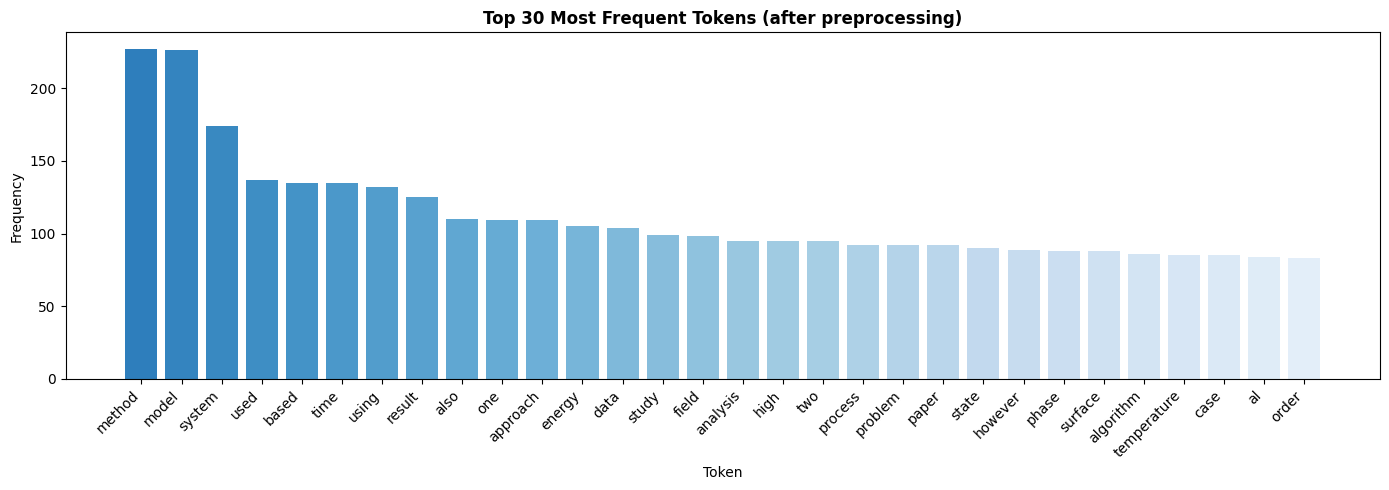

In [39]:
all_tokens = ' '.join(df['processed_text']).split()
token_freq = Counter(all_tokens)
top30 = token_freq.most_common(30)
words30, counts30 = zip(*top30)

plt.figure(figsize=(14, 5))
plt.bar(words30, counts30,
        color=plt.cm.Blues_r(np.linspace(0.3, 0.9, 30)))
plt.xticks(rotation=45, ha='right')
plt.title('Top 30 Most Frequent Tokens (after preprocessing)', fontweight='bold')
plt.xlabel('Token')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

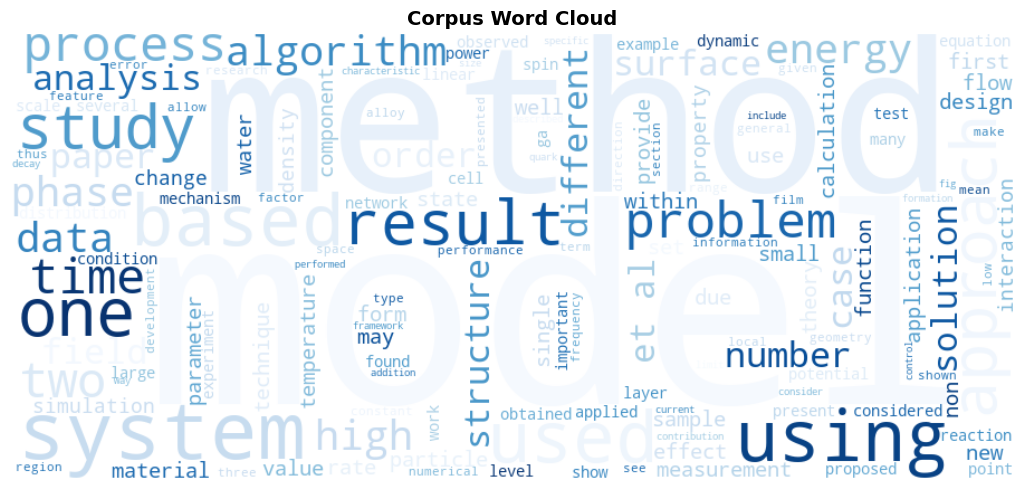

In [40]:
wc = WordCloud(width=900, height=400, background_color='white',
               colormap='Blues', max_words=150)
wc.generate(' '.join(df['processed_text']))

plt.figure(figsize=(14, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Corpus Word Cloud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Extraction

### 4a. TF-IDF Vectorization

In [41]:
from src.features import tfidf_vec
tfidf_vectorizer = tfidf_vec()

tfidf_matrix = tfidf_vectorizer.fit_transform(df['processed_text'])
print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'  {tfidf_matrix.shape[0]} documents x {tfidf_matrix.shape[1]} features')

TF-IDF matrix shape: (350, 4078)
  350 documents x 4078 features


### 4b. Sentence-BERT Embeddings

In [42]:
from src.features import sbert
SUBSET = min(500, len(df))

sbert_model = sbert()
doc_embeddings = sbert_model.encode(
        df['text'].tolist()[:SUBSET],
        show_progress_bar=True,
        batch_size=64
    )
print(f'Embeddings shape: {doc_embeddings.shape}')

Loading Sentence-BERT model...


Batches: 100%|██████████| 6/6 [00:12<00:00,  2.07s/it]

Embeddings shape: (350, 384)


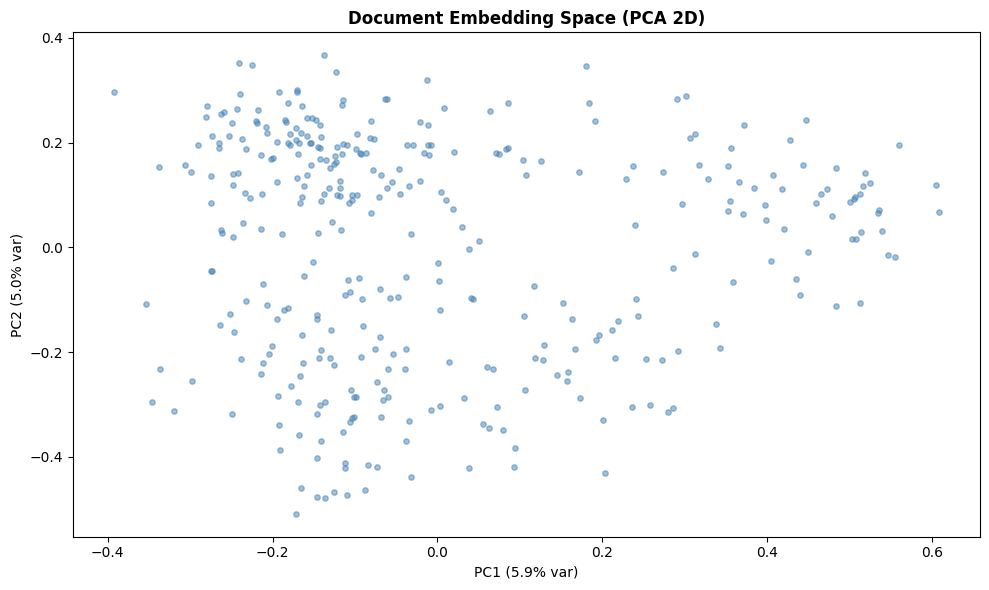

In [43]:
pca    = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(doc_embeddings)

plt.figure(figsize=(10, 6))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], alpha=0.5, s=15, c='steelblue')
plt.title('Document Embedding Space (PCA 2D)', fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.tight_layout()
plt.show()

## 5. Baseline Method — TF-IDF Keyword Extraction

In [44]:
from src.extraction import extract_keywords_tfidf

# Demo
print('=== TF-IDF Baseline — Sample Extractions ===')
for idx in range(5):
    text = df['text'].iloc[idx]
    kws  = extract_keywords_tfidf(text, tfidf_vectorizer, top_n=8)
    print(f'\n[Doc {idx}] {text[:100].strip()}...')
    print(f'  Keywords: {[k for k,s in kws]}')

=== TF-IDF Baseline — Sample Extractions ===

[Doc 0] Amodel are proposed for modeling data-centric Web services which are powered by relational databases...
  Keywords: ['web', 'service', 'constraint', 'output', 'input', 'action', 'formula', 'data']

[Doc 1] In this Letter we revisit the Chesnavich model Hamiltonian [37] in the light of recent developments...
  Keywords: ['phase space', 'well defined', 'tt', 'model hamiltonian', 'identification', 'hamiltonian', 'clearly', 'goal']

[Doc 2] Experimental studies of the dynamics of individual carbon atoms in graphene have been empowered by t...
  Keywords: ['fullerene', 'ac', 'tem', 'vacancy', 'formation', 'beam', 'edge', 'self assembly']

[Doc 3] The need for power generation industry to improve the thermal efficiency of power plant has led to t...
  Keywords: ['cyclic', 'power plant', 'thermal', 'plant', 'power', 'cause', 'steel', 'recently']

[Doc 4] We deal with the intensity scattered by a random mixture of deuterated/hydrogenated PE

In [45]:
df['tfidf_keywords'] = df['text'].apply(
    lambda t: [k for k, s in extract_keywords_tfidf(t, tfidf_vectorizer, top_n=10)]
)
print('TF-IDF keywords extracted for all documents.')
display(df[['text', 'tfidf_keywords']].head(3))

TF-IDF keywords extracted for all documents.


,text,tfidf_keywords
0,Amodel are proposed for modeling data-centric ...,"[web, service, constraint, output, input, acti..."
1,In this Letter we revisit the Chesnavich model...,"[phase space, well defined, tt, model hamilton..."
2,Experimental studies of the dynamics of indivi...,"[fullerene, ac, tem, vacancy, formation, beam,..."


## 6. Advanced Method — KeyBERT (Embedding-Based)

In [46]:
kw_model = KeyBERT(model=sbert_model)
print('KeyBERT model ready.')

KeyBERT model ready.


In [47]:
from src.extraction import extract_keywords_keybert

# Demo
print('=== KeyBERT Advanced — Sample Extractions ===')
for idx in range(5):
    text = df['text'].iloc[idx]
    kws  = extract_keywords_keybert(text, kw_model, top_n=8)
    print(f'\n[Doc {idx}] {text[:100].strip()}...')
    print(f'  Keywords: {[k for k,s in kws]}')

=== KeyBERT Advanced — Sample Extractions ===

[Doc 0] Amodel are proposed for modeling data-centric Web services which are powered by relational databases...
  Keywords: ['logic ltl', 'web services', 'automatic verification', 'constraints decidable', 'data centric', 'amodel proposed', 'specifications using', 'existing verifier']

[Doc 1] In this Letter we revisit the Chesnavich model Hamiltonian [37] in the light of recent developments...
  Keywords: ['chesnavich model', 'periodic orbit', 'barrierless systems', 'ion molecule', 'hamiltonian associated', 'roaming mechanism', 'defined phase', 'dividing surfaces']

[Doc 2] Experimental studies of the dynamics of individual carbon atoms in graphene have been empowered by t...
  Keywords: ['atoms graphene', 'fullerene formation', 'electron microscopy', 'protrusion nanotube', 'defects edge', 'radiation proposed', 'reconstruction formation', 'small finite']

[Doc 3] The need for power generation industry to improve the thermal efficiency of p

In [48]:
print(f'Running KeyBERT on {SUBSET} documents...')
keybert_list = []
for i, text in enumerate(df['text'].iloc[:SUBSET]):
    kws = [k for k, s in extract_keywords_keybert(text, kw_model, top_n=10)]
    keybert_list.append(kws)
    if (i + 1) % 100 == 0:
        print(f'  Processed {i+1}/{SUBSET}')

df.loc[:SUBSET-1, 'keybert_keywords'] = pd.Series(keybert_list, index=range(SUBSET))
print('KeyBERT keywords extracted!')

Running KeyBERT on 350 documents...
  Processed 100/350
  Processed 200/350
  Processed 300/350
KeyBERT keywords extracted!


## 7. Evaluation

### 7a. Automatic Evaluation (if gold keywords available)

In [49]:
from src.evaluation import prf, parse_gold

edf = df.iloc[:SUBSET].copy()
edf['gold'] = edf.apply(parse_gold, axis=1)
t_scores  = edf.apply(lambda r: prf(r['tfidf_keywords'],
                                      r['gold']), axis=1)
kb_scores = edf.apply(lambda r: prf(
    r['keybert_keywords'] if isinstance(r.get('keybert_keywords'), list) else [],
    r['gold']), axis=1)

t_avg  = pd.DataFrame(t_scores.tolist()).mean().round(4)
kb_avg = pd.DataFrame(kb_scores.tolist()).mean().round(4)

results = pd.DataFrame({'TF-IDF': t_avg, 'KeyBERT': kb_avg})
print('Evaluation Results (corpus average):')
display(results)

Evaluation Results (corpus average):


,TF-IDF,KeyBERT
precision,0.1391,0.1403
recall,0.0840,0.0904
f1,0.1008,0.1059


In [50]:
print("Sample gold:", edf['gold'].iloc[0])
print("TF-IDF:", edf['tfidf_keywords'].iloc[0])
print("KeyBERT:", edf['keybert_keywords'].iloc[0])

Sample gold: {'state/output/action rules', 'ltl-fo', 'data-centric web services', 'verify web service specifications', 'linear temporal first-order logic', 'data-centric web applications', 'relational databases', 'reducing web services to data-centric web applications', 'web applications', 'modeling data-centric web services', 'interact with users', 'logical formulas', 'control-flow constraints'}
TF-IDF: ['web', 'service', 'constraint', 'output', 'input', 'action', 'formula', 'data', 'verification', 'specification']
KeyBERT: ['logic ltl', 'web services', 'automatic verification', 'constraints decidable', 'data centric', 'amodel proposed', 'specifications using', 'existing verifier', 'control flow', 'bounded']


### 7b. Qualitative Side-by-Side Comparison

In [52]:
print('=' * 75)
print('  SIDE-BY-SIDE: TF-IDF  vs  KeyBERT')
print('=' * 75)

for idx in range(5):
    row = df.iloc[idx]
    print(f'\nDoc {idx}: {row['text'][:200]}...')
    print(f'  TF-IDF  : {row["tfidf_keywords"][:6]}')
    kb = row.get('keybert_keywords')
    print(f'  KeyBERT : {kb[:6] if isinstance(kb, list) else "N/A"}')
    if 'keyphrases':
        print(f'  GOLD    : {sorted(parse_gold(row))[:6]}')
    print('-' * 70)

  SIDE-BY-SIDE: TF-IDF  vs  KeyBERT

Doc 0: Amodel are proposed for modeling data-centric Web services which are powered by relational databases and interact with users according to logical formulas specifying input constraints, control-flow co...
  TF-IDF  : ['web', 'service', 'constraint', 'output', 'input', 'action']
  KeyBERT : ['logic ltl', 'web services', 'automatic verification', 'constraints decidable', 'data centric', 'amodel proposed']
  GOLD    : ['control-flow constraints', 'data-centric web applications', 'data-centric web services', 'interact with users', 'linear temporal first-order logic', 'logical formulas']
----------------------------------------------------------------------

Doc 1: In this Letter we revisit the Chesnavich model Hamiltonian [37] in the light of recent developments in TST. For barrierless systems such as ion–molecule reactions, the concepts of OTS and TTS can be c...
  TF-IDF  : ['phase space', 'well defined', 'tt', 'model hamiltonian', 'identificati

### 7c. Metric Visualization

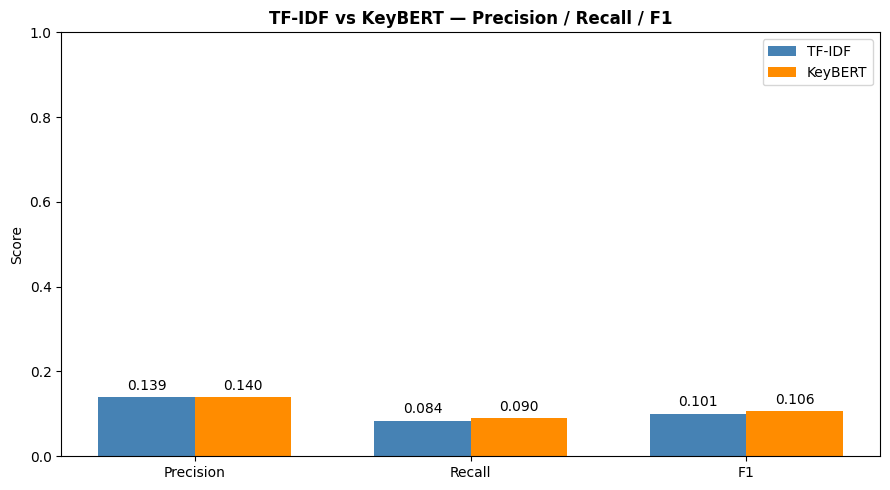

In [53]:
if 'keyphrases':
    metrics = ['precision', 'recall', 'f1']
    x, w = np.arange(len(metrics)), 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    b1 = ax.bar(x - w/2, t_avg[metrics],  w, label='TF-IDF',  color='steelblue')
    b2 = ax.bar(x + w/2, kb_avg[metrics], w, label='KeyBERT', color='darkorange')

    ax.set_title('TF-IDF vs KeyBERT — Precision / Recall / F1', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Precision', 'Recall', 'F1'])
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score')
    ax.legend()
    ax.bar_label(b1, fmt='%.3f', padding=3)
    ax.bar_label(b2, fmt='%.3f', padding=3)
    plt.tight_layout()
    plt.show()
else:
    print('Metric chart requires a gold keywords column in the dataset.')

### 7d. Confusion Matrix & Accuracy

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from src.evaluation import  build_binary_labels



# ── Build labels for both methods ─────────────────────────────────────────────
print("Building binary labels... (this may take a moment)")

y_true_t,  y_pred_t  = build_binary_labels(edf, 'tfidf_keywords',   'gold', tfidf_vectorizer)
y_true_kb, y_pred_kb = build_binary_labels(edf, 'keybert_keywords',  'gold', tfidf_vectorizer)

print(f"Label pairs per method: {len(y_true_t):,}")

Building binary labels... (this may take a moment)
Label pairs per method: 1,427,300


In [55]:
# ── Accuracy ──────────────────────────────────────────────────────────────────
acc_tfidf   = (y_true_t  == y_pred_t ).mean()
acc_keybert = (y_true_kb == y_pred_kb).mean()

print(f"\n{'Method':<12} {'Accuracy':>10}")
print("-" * 24)
print(f"{'TF-IDF':<12} {acc_tfidf:>10.4f}")
print(f"{'KeyBERT':<12} {acc_keybert:>10.4f}")


Method         Accuracy
------------------------
TF-IDF           0.9975
KeyBERT          0.9994


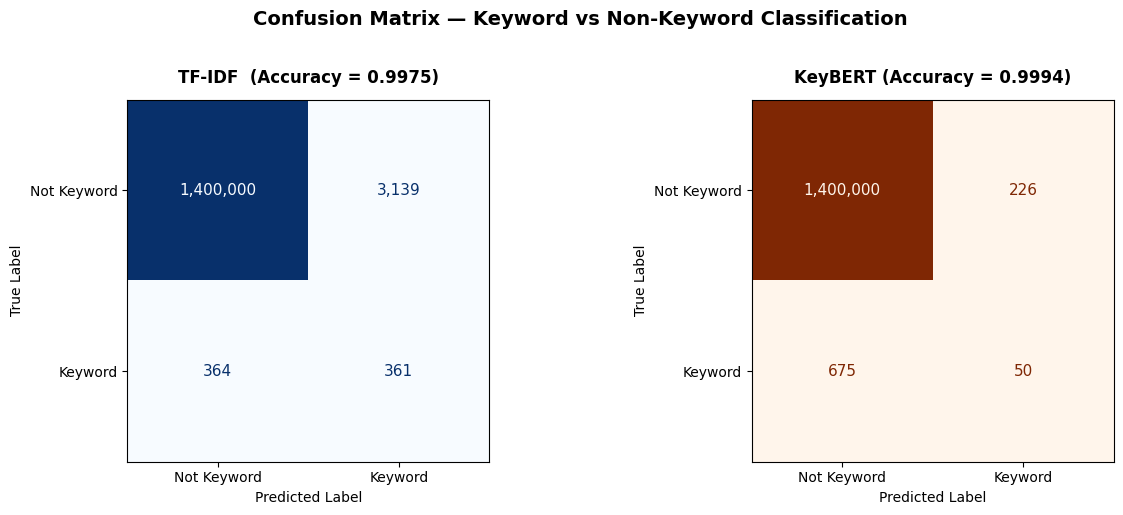

In [56]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
cm_t  = confusion_matrix(y_true_t,  y_pred_t)
cm_kb = confusion_matrix(y_true_kb, y_pred_kb)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Confusion Matrix — Keyword vs Non-Keyword Classification",
             fontsize=14, fontweight='bold', y=1.02)

for ax, cm, title, color in [
    (axes[0], cm_t,  f"TF-IDF  (Accuracy = {acc_tfidf:.4f})",   "Blues"),
    (axes[1], cm_kb, f"KeyBERT (Accuracy = {acc_keybert:.4f})",  "Oranges"),
]:
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Keyword", "Keyword"]
    )
    disp.plot(ax=ax, colorbar=False, cmap=color)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label",      fontsize=10)

    # Annotate cells with formatted numbers
    for text in ax.texts:
        try:
            val = int(float(text.get_text()))
            text.set_text(f"{val:,}")
        except ValueError:
            pass
        text.set_fontsize(11)

plt.tight_layout()
plt.show()


In [57]:
# ── Summary table ─────────────────────────────────────────────────────────────
cm_labels = ["TN", "FP", "FN", "TP"]

summary = pd.DataFrame({
    "Metric":  ["TN (correct non-keywords)",
                "FP (false alarms)",
                "FN (missed keywords)",
                "TP (correct keywords)",
                "Accuracy",
                "Precision",
                "Recall",
                "F1-Score"],
    "TF-IDF":  [
        f"{cm_t.ravel()[0]:,}",
        f"{cm_t.ravel()[1]:,}",
        f"{cm_t.ravel()[2]:,}",
        f"{cm_t.ravel()[3]:,}",
        f"{acc_tfidf:.4f}",
        f"{t_avg['precision']:.4f}",
        f"{t_avg['recall']:.4f}",
        f"{t_avg['f1']:.4f}",
    ],
    "KeyBERT": [
        f"{cm_kb.ravel()[0]:,}",
        f"{cm_kb.ravel()[1]:,}",
        f"{cm_kb.ravel()[2]:,}",
        f"{cm_kb.ravel()[3]:,}",
        f"{acc_keybert:.4f}",
        f"{kb_avg['precision']:.4f}",
        f"{kb_avg['recall']:.4f}",
        f"{kb_avg['f1']:.4f}",
    ],
})

print("\nFull Evaluation Summary:")
display(summary)


Full Evaluation Summary:


,Metric,TF-IDF,KeyBERT
0,TN (correct non-keywords),"1,423,436","1,426,349"
1,FP (false alarms),"3,139",226
2,FN (missed keywords),364,675
3,TP (correct keywords),361,50
4,Accuracy,0.9975,0.9994
5,Precision,0.1391,0.1403
6,Recall,0.0840,0.0904
7,F1-Score,0.1008,0.1059


### 7e. Keyword Overlap (Jaccard)

Average Jaccard overlap (TF-IDF vs KeyBERT): 0.013


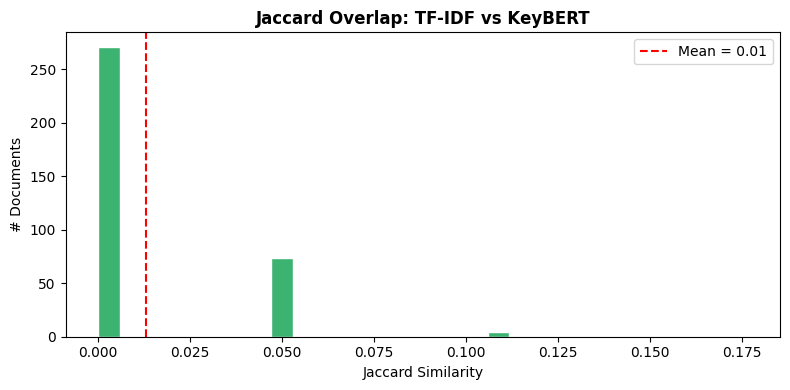

In [58]:
overlaps = []
for idx in range(SUBSET):
    row = df.iloc[idx]
    t_set  = set(row['tfidf_keywords'])
    kb_raw = row.get('keybert_keywords', [])
    k_set  = set(kb_raw) if isinstance(kb_raw, list) else set()
    union  = t_set | k_set
    if union:
        overlaps.append(len(t_set & k_set) / len(union))

print(f'Average Jaccard overlap (TF-IDF vs KeyBERT): {np.mean(overlaps):.3f}')

plt.figure(figsize=(8, 4))
plt.hist(overlaps, bins=30, color='mediumseagreen', edgecolor='white')
plt.axvline(np.mean(overlaps), color='red', linestyle='--',
            label=f'Mean = {np.mean(overlaps):.2f}')
plt.title('Jaccard Overlap: TF-IDF vs KeyBERT', fontweight='bold')
plt.xlabel('Jaccard Similarity')
plt.ylabel('# Documents')
plt.legend()
plt.tight_layout()
plt.show()

### 7f. Top Corpus Keywords

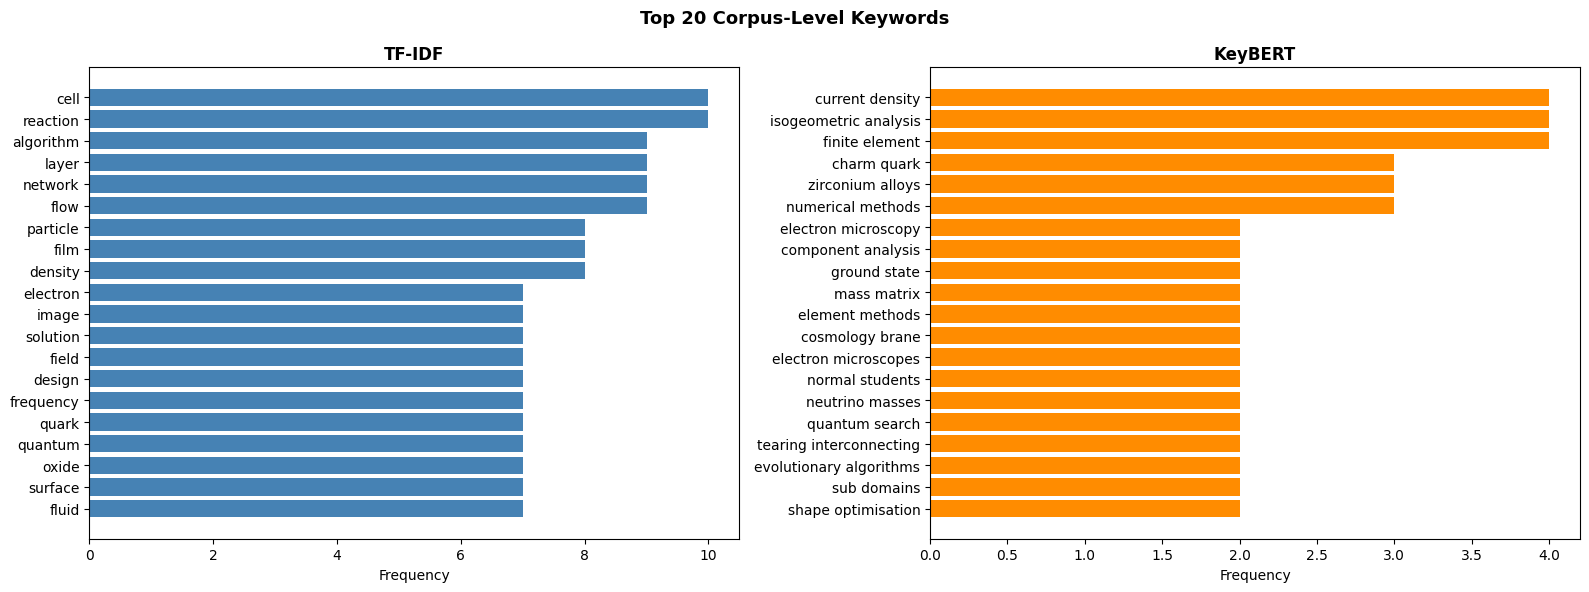

In [59]:
all_t  = [kw for kws in df['tfidf_keywords'] for kw in kws]
all_kb = [kw for kws in df['keybert_keywords'].dropna()
          for kw in (kws if isinstance(kws, list) else [])]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 20 Corpus-Level Keywords', fontweight='bold', fontsize=13)

for ax, data, title, color in [
    (axes[0], Counter(all_t).most_common(20),  'TF-IDF',  'steelblue'),
    (axes[1], Counter(all_kb).most_common(20), 'KeyBERT', 'darkorange'),
]:
    if data:
        words, counts = zip(*data)
        ax.barh(list(reversed(words)), list(reversed(counts)), color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

## 8. Save Results

In [60]:
import os

output_path = 'results/keyword_extraction_results.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)

save_cols = [c for c in ['text', 'keyphrases',
                          'processed_text',
                          'tfidf_keywords',
                          'keybert_keywords']
             if c and c in df.columns]

df[save_cols].to_csv(output_path, index=False)
print(f'Results saved to: {output_path}')

Results saved to: results/keyword_extraction_results.csv


In [61]:
# ==========================================
# SAVE ALL COMPONENTS
# ==========================================

import os
import joblib
import pickle

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

STOPWORDS  = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
# Create models directory
os.makedirs("models", exist_ok=True)

# ==========================================
# SAVE TF-IDF VECTORIZER
# ==========================================
joblib.dump(tfidf_vectorizer, "models/tfidf_vectorizer.pkl")

print("TF-IDF vectorizer saved.")


# ==========================================
# SAVE SBERT MODEL NAME
# (recommended instead of full pickle)
# ==========================================

SBERT_MODEL_NAME = "all-MiniLM-L6-v2"

with open("models/sbert_model_name.pkl", "wb") as f:
    pickle.dump(SBERT_MODEL_NAME, f)

print("SBERT model name saved.")


# ==========================================
# SAVE KEYBERT MODEL
# ==========================================
joblib.dump(kw_model, "models/keybert_model.pkl")

print("KeyBERT model saved.")


# ==========================================
# SAVE STOPWORDS
# ==========================================
joblib.dump(STOPWORDS, "models/stopwords.pkl")

print("Stopwords saved.")


# ==========================================
# SAVE LEMMATIZER
# ==========================================
joblib.dump(lemmatizer, "models/lemmatizer.pkl")

print("Lemmatizer saved.")


print("\nAll components saved successfully.")

TF-IDF vectorizer saved.
SBERT model name saved.
KeyBERT model saved.
Stopwords saved.
Lemmatizer saved.

All components saved successfully.
